# Pronunciation Scoring — Inference Notebook

Run end-to-end pronunciation scoring on any audio file (WAV / MP3 / FLAC / …)  
or a raw NumPy waveform array.

**Pipeline:**
```
Raw audio  →  HuBERT (layer-weighted)  →  Cross-attention fusion (+ Qwen3 text)  →  Transformer block  →  MLP  →  5-dim scores
```

## 1 · Imports

In [12]:
# All heavy imports are encapsulated in notebook_infer/
from notebook_infer import ScoreConfig, load_predictor, score_file, score_array
from notebook_infer.display import show_scores, show_words, show_waveform, play_audio

## 2 · Configuration

In [13]:
import torch

cfg = ScoreConfig(
    checkpoint   = "ckpt_hubert_multitask/best.pt",  # set to None for untrained random weights
    device       = "cuda" if torch.cuda.is_available() else "cpu",
    whisper_size = "small",                           # ASR model size: tiny / small / medium
    language     = "en",                              # ISO-639-1 language code
    text_model   = "Qwen/Qwen3-Embedding-0.6B",       # text embedding model
)
print(cfg)

ScoreConfig(checkpoint='ckpt_hubert_multitask/best.pt', device='cpu', whisper_size='small', language='en', text_model='Qwen/Qwen3-Embedding-0.6B')


## 3 · Load model

This downloads HuBERT and Qwen3-Embedding on first run (~700 MB total).  
Subsequent runs load from the HuggingFace cache.

In [14]:
predictor = load_predictor(cfg)
print("Model ready.")

Loading weights: 100%|██████████| 310/310 [00:00<00:00, 858.90it/s, Materializing param=norm.weight]                              


Model ready.


---
## 4A · Score from a file path

In [15]:
WAV_PATH = "audio/native_speaker/01_native.wav"   # ← change to your audio file

result = score_file(WAV_PATH, predictor, cfg)

---
## 4B · Score from a raw NumPy array

Use this if you already have the waveform in memory (e.g. from `soundfile.read` or `librosa.load`).

In [16]:
import numpy as np
import soundfile as sf

# Load raw audio into a NumPy array (replace with your own source)
audio_np, sample_rate = sf.read(WAV_PATH, dtype="float32", always_2d=False)
print(f"Audio shape: {audio_np.shape}  |  Sample rate: {sample_rate} Hz")

# Score directly from the array
result = score_array(audio_np, sample_rate, predictor, cfg)

Audio shape: (77360,)  |  Sample rate: 16000 Hz


---
## 5 · Display results

In [17]:
show_scores(result)

Dimension,Score / 10
Total,5.33
Accuracy,4.55
Fluency,6.18
Prosodic,4.08
Completeness,4.65


In [18]:
show_words(result)

Word,Start,End,Score
Hurstwood,0.000s,0.740s,n/a
walked,0.740s,0.960s,n/a
the,0.960s,1.200s,n/a
"floor,",1.200s,1.400s,n/a
mentally,1.560s,1.860s,n/a
arranging,1.860s,2.480s,n/a
the,2.480s,2.720s,n/a
chief,2.720s,2.920s,n/a
points,2.920s,3.240s,n/a
of,3.240s,3.400s,n/a


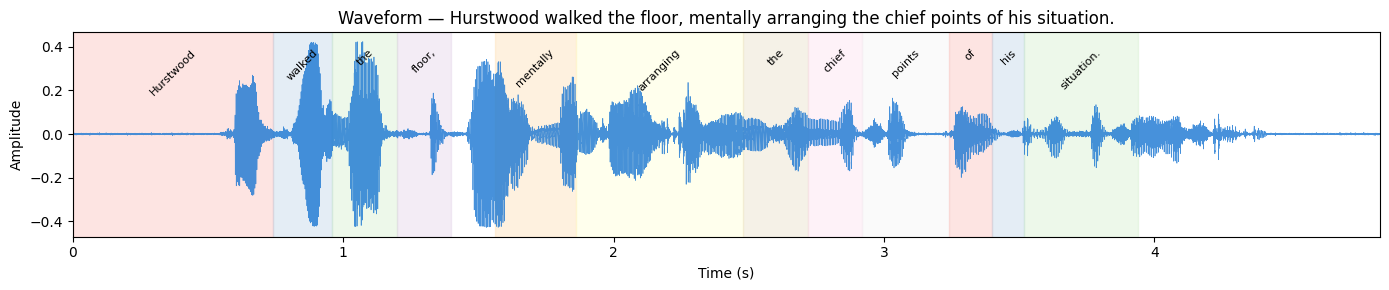

In [19]:
show_waveform(WAV_PATH, result)

In [20]:
play_audio(WAV_PATH)

---
## 6 · Raw JSON output

In [21]:
import json
print(json.dumps(result, indent=2, ensure_ascii=False))

{
  "accuracy": 4.551188051700592,
  "completeness": 4.645931124687195,
  "fluency": 6.177936792373657,
  "prosodic": 4.078626036643982,
  "total": 5.330222845077515,
  "text": "Hurstwood walked the floor, mentally arranging the chief points of his situation.",
  "words": [
    {
      "text": "Hurstwood",
      "accuracy": null,
      "stress": null,
      "total": null,
      "phones": [],
      "phones-accuracy": [],
      "mispronunciations": [],
      "start": 0.0,
      "end": 0.74,
      "asr_prob": 0.6955352226893107
    },
    {
      "text": "walked",
      "accuracy": null,
      "stress": null,
      "total": null,
      "phones": [],
      "phones-accuracy": [],
      "mispronunciations": [],
      "start": 0.74,
      "end": 0.96,
      "asr_prob": 0.9922802448272705
    },
    {
      "text": "the",
      "accuracy": null,
      "stress": null,
      "total": null,
      "phones": [],
      "phones-accuracy": [],
      "mispronunciations": [],
      "start": 0.96,
      

---
## 7 · Batch scoring

Score multiple files and collect results into a DataFrame.

In [22]:
# import glob
# import pandas as pd

# audio_files = glob.glob("audio/**/*.wav", recursive=True)
# print(f"Found {len(audio_files)} audio files.")

# rows = []
# for path in audio_files:
#     r = score_file(path, predictor, cfg)
#     rows.append({
#         "file":         path,
#         "transcript":   r.get("text"),
#         "total":        r.get("total"),
#         "accuracy":     r.get("accuracy"),
#         "fluency":      r.get("fluency"),
#         "prosodic":     r.get("prosodic"),
#         "completeness": r.get("completeness"),
#     })

# df = pd.DataFrame(rows)
# df